# Standard DSPOT and its modifications

Here, we apply DSPOT and its modificationd to the realTraffic dataset. We are looking to see under which conditions algorithm does perform well, what the main improvement areas and how to modify DSPOT making it more robust to non-stationary data

### Standard DSPOT

In [1]:
# Load the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from evt_checks import plot_evt_diagnostics
from spot_copy import SPOT, dSPOT, ModifiedSPOT, moving_average, OnlinePreprocessor
from eqd import eqd

from scipy.stats import median_abs_deviation
from statsmodels.tsa.seasonal import STL
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf
from collections import deque
from itertools import product


# Load the data
df2 = pd.read_csv("../../data/clean_data/post_gap_occupancy.csv", parse_dates=[0], index_col=0)
df2.columns = ["value"]
series_raw = df2['value']
#df2.columns = ["timestamp", "value"]
#data = df2.iloc[:, 1].values  # use second column for DSPOT

# Load the labels
with open("../../data/raw_data/combined_windows.json") as f:
    all_windows = json.load(f)

dataset_key = "realTraffic/occupancy_6005.csv" # set the key 
window_strs = all_windows.get(dataset_key, []) # get the list of window strings

# Convert to datetime tuples
anomaly_windows = [
    (datetime.strptime(start, "%Y-%m-%d %H:%M:%S.%f"),
     datetime.strptime(end, "%Y-%m-%d %H:%M:%S.%f"))
    for start, end in window_strs
]

### Vanilla Dspot

In [2]:
# Reload data, preload timestamps & anomaly windows
df2 = pd.read_csv("../../data/clean_data/post_gap_occupancy.csv", parse_dates=[0])
df2.columns = ["timestamp", "value"]
timestamps  = pd.to_datetime(df2.iloc[:, 0])

def align_windows_to_series(windows, ts_series):
    """
    Convert a list of (start,end) datetimes to pandas Timestamps that match the
    timezone-awareness of ts_series (Series or DatetimeIndex).
    """
    idx = pd.to_datetime(ts_series)
    # Get tz info depending on type
    if isinstance(idx, pd.Series):
        tz = idx.dt.tz
    elif isinstance(idx, pd.DatetimeIndex):
        tz = idx.tz
    else:
        tz = None

    aligned = []
    for s, e in windows:
        s_ts = pd.Timestamp(s)
        e_ts = pd.Timestamp(e)
        if e_ts < s_ts:
            s_ts, e_ts = e_ts, s_ts

        if tz is None:
            # force naive
            s_ts = s_ts.tz_localize(None) if s_ts.tzinfo else s_ts
            e_ts = e_ts.tz_localize(None) if e_ts.tzinfo else e_ts
        else:
            # ensure aware and convert
            s_ts = (s_ts.tz_localize("UTC") if s_ts.tzinfo is None else s_ts).tz_convert(tz)
            e_ts = (e_ts.tz_localize("UTC") if e_ts.tzinfo is None else e_ts).tz_convert(tz)

        aligned.append((s_ts, e_ts))
    return aligned

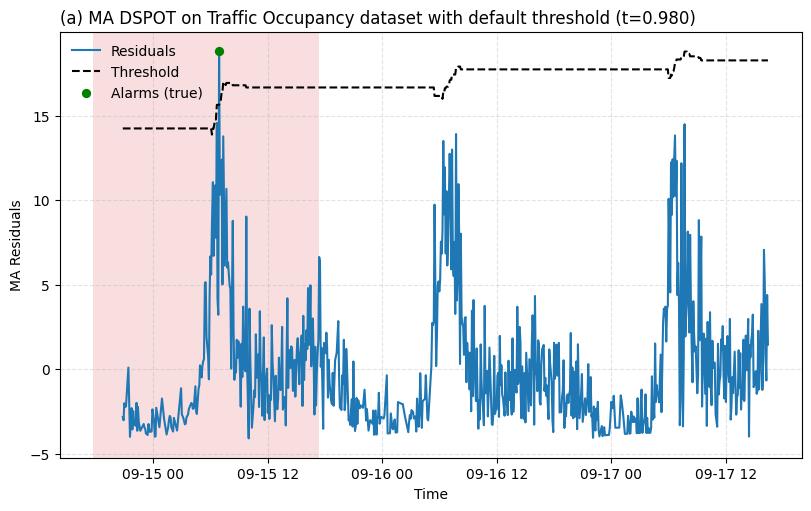

In [6]:
# Prep the time index to match the full series length
full_index = series_raw.index

# Build ground-truth anomaly windows aligned to this index
with open("../../data/raw_data/combined_windows.json") as f:
    all_windows = json.load(f)
dataset_key = "realTraffic/occupancy_6005.csv"

from datetime import datetime
window_strs = all_windows.get(dataset_key, [])
raw_windows = [
    (datetime.strptime(start, "%Y-%m-%d %H:%M:%S.%f"),
     datetime.strptime(end,   "%Y-%m-%d %H:%M:%S.%f"))
    for start, end in window_strs
]

def merge_overlapping(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(s, e) for s, e in merged]
anomaly_windows_dt = merge_overlapping(align_windows_to_series(raw_windows, full_index))
anomaly_windows_dt = [(max(s, full_index.min()), min(e, full_index.max()))
                      for s, e in anomaly_windows_dt if max(s, full_index.min()) <= min(e, full_index.max())]

# Set parameters
init_data = 1000        
proba     = 1e-3 
depth     = 288 
init_batch = series_raw[:init_data].values

# Run dSPOT
model = dSPOT(q=proba, depth=depth)
model.fit(init_data=init_batch, data=series_raw[init_data:].values)
model.initialize()
results = model.run(with_alarm=True)

# Plot the results 
fig, ax = model.plot(
    results,
    with_alarm=True,
    figsize=(8, 5),
    title="(a) MA DSPOT on Traffic Occupancy dataset with default threshold (t=0.980)",
    label="MA Residuals",
    data_color="tab:blue",    
    threshold_color="black",    
    true_alarm_color="green",  
    false_alarm_color="red",
    shade_color="tab:red", shade_alpha=0.15, 
    ts_index=full_index,   
    anomaly_windows=anomaly_windows_dt 
)
fig.savefig("../../output/occupancy/original_dspot_occupancy.png", dpi=300)
plt.show()

In [4]:
## Event-based Evaluation
# Parameters + mapping 
offsets  = np.array(results["alarms"], dtype=int)
detected = timestamps.iloc[init_data + offsets].sort_values().to_list()

# Collapse consecutive alarms into alarm events
min_gap = pd.Timedelta("5min")
alarm_events = []
if detected:
    ev_start = detected[0]
    ev_end   = detected[0]
    for t in detected[1:]:
        if t - ev_end > min_gap:  
            alarm_events.append((ev_start, ev_end))
            ev_start = t
        ev_end = t
    alarm_events.append((ev_start, ev_end))

# Sort ground-truth windows + introduce "earliest unmatched" rule
gt_windows = sorted(list(anomaly_windows), key=lambda w: w[0])  # ensure sorted
TP, FP = 0, 0
delays = []
matched_gt = set()

for (a_start, a_end) in alarm_events:
    # find indices of ground-truth windows
    overlaps = [i for i, (g_start, g_end) in enumerate(gt_windows)
                if not (a_end < g_start or a_start > g_end)]
    if overlaps:
        # assign to earliest unmatched overlapping GT window, if any
        assigned = False
        for i in overlaps:
            if i not in matched_gt:
                matched_gt.add(i)
                TP += 1
                g_start = gt_windows[i][0]
                # define delay 
                delay_min = max(0.0, (a_start - g_start).total_seconds() / 60.0)
                delays.append(delay_min)
                assigned = True
                break
        if not assigned:
            pass
    else:
        FP += 1

FN = len(gt_windows) - TP

# Compute metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
recall    = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
f1        = (2 * precision * recall / (precision + recall)
             if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
             else float("nan"))
mean_delay   = np.nanmean(delays)  if delays else float("nan")
median_delay = np.nanmedian(delays) if delays else float("nan")

print(f"TP={TP}, FP={FP}, FN={FN}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
print(f"Median delay = {median_delay:.1f} min")


TP=1, FP=0, FN=0
Precision=1.000  Recall=1.000  F1=1.000
Median delay = 790.0 min


TP=1, FP=0, FN=0
Precision=1.000  Recall=1.000  F1=1.000
Median delay = 790.0 min

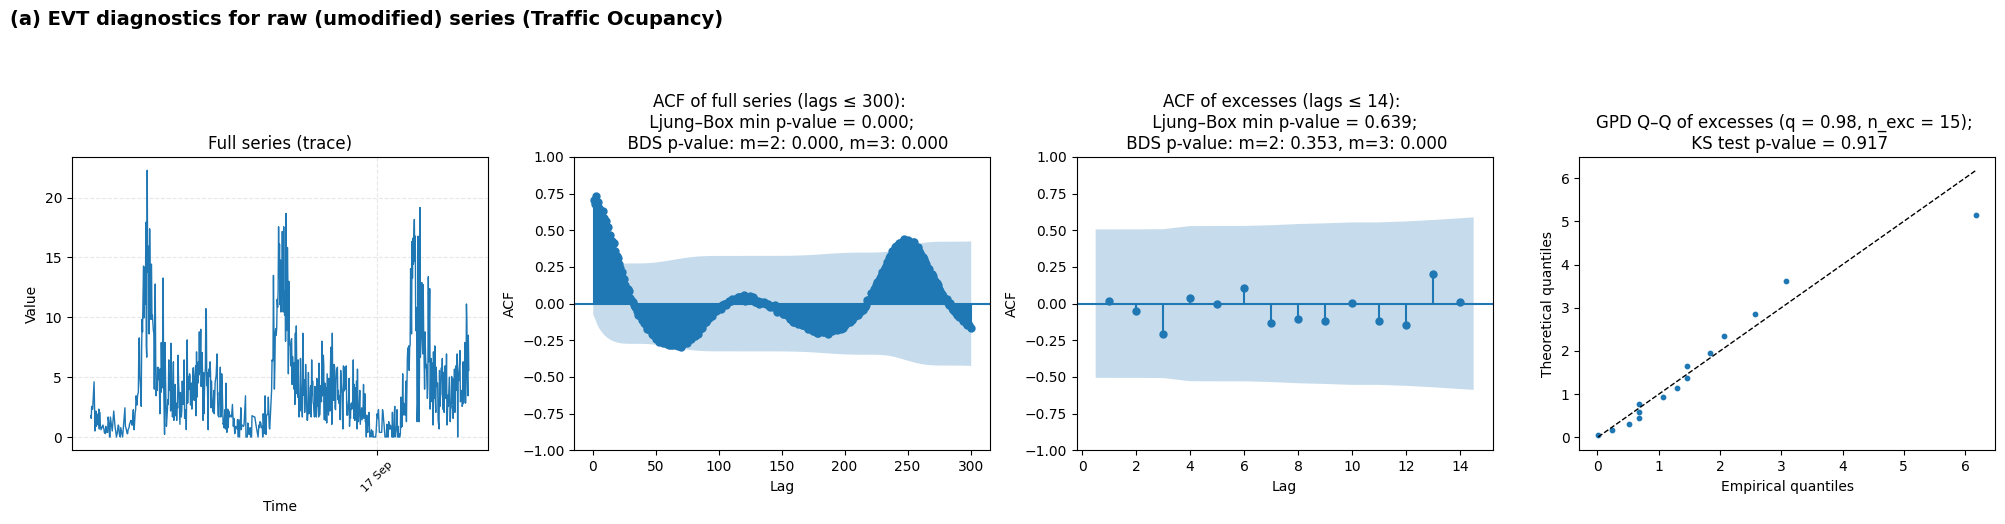

In [6]:
df2 = pd.read_csv("../../data/clean_data/post_gap_occupancy.csv", parse_dates=[0], header=0)
df2.columns = ["timestamp", "value"]
s_raw = df2.set_index("timestamp")["value"].astype(float)
s_raw = s_raw.iloc[1000:]

fig = plot_evt_diagnostics(s_raw, exceed_q=0.98, acf_lags=300, bds_max_dim=3, 
                           title="(a) EVT diagnostics for raw (umodified) series (Traffic Ocupancy)")
plt.show(fig)
fig.savefig("../../output/occupancy/evt_raw_diagnostics_occupancy.png", dpi=300, bbox_inches='tight')

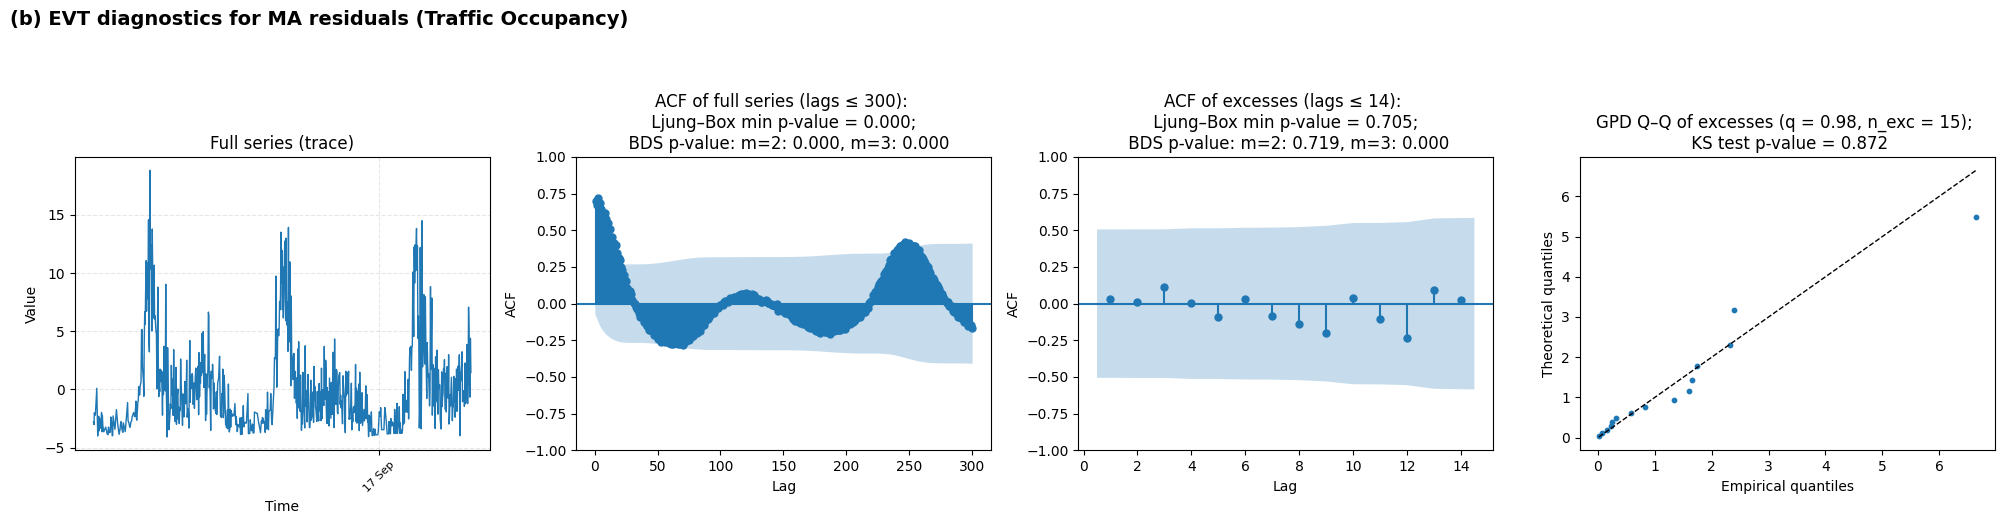

In [7]:
# print evt diagnostic for the residuals used in vanilla dSPOT
residuals  = np.array(results["residuals"])
raw_index = series_raw.index
resid_series = pd.Series(residuals, index=raw_index)
clean_resid = resid_series.dropna()

fig = plot_evt_diagnostics(clean_resid, exceed_q=0.98, acf_lags=300, bds_max_dim=3, 
                           title="(b) EVT diagnostics for MA residuals (Traffic Occupancy)")
plt.show(fig)
fig.savefig("../../output/occupancy/evt_ma_diagnostics_occupancy.png", dpi=300, bbox_inches='tight')

In [ ]:
Next, we use rigourosly chosen first cutoff threshold on the Vanilla DSPOT to se wether it will improve the fit

In [7]:
# Set parameters
init_data = 1000
depth = 288
proba = 1e-3
init_batch = series_raw[:init_data].values

# Compute MA residuals using the dSPOT logic
residuals = init_batch[depth:] - moving_average(init_batch, depth)[:-1]

# Run EQD on residuals
thresholds = np.quantile(residuals, np.linspace(0.85, 0.99, 30))
np.random.seed(27)
result = eqd(residuals, thresholds)
u_gpd = result["threshold"]
param = result["params"]

# Compute level
level = np.mean(residuals <= u_gpd)

print("Selected threshold:", u_gpd)
print("GPD parameters:", param)
print("Estimated as quantile level: ", np.mean(residuals <= result["threshold"]))
print("Num peaks:", np.sum(residuals > u_gpd))
print("Max peak value:", residuals[residuals > u_gpd].max())
print("Mean peak value:", residuals[residuals > u_gpd].mean())

Selected threshold: 7.560312751436782
GPD parameters: (1.9880908771019379, -0.04166640860230242)
Estimated as quantile level:  0.9747191011235955
Num peaks: 18
Max peak value: 14.133263888888884
Mean peak value: 9.468094135802467


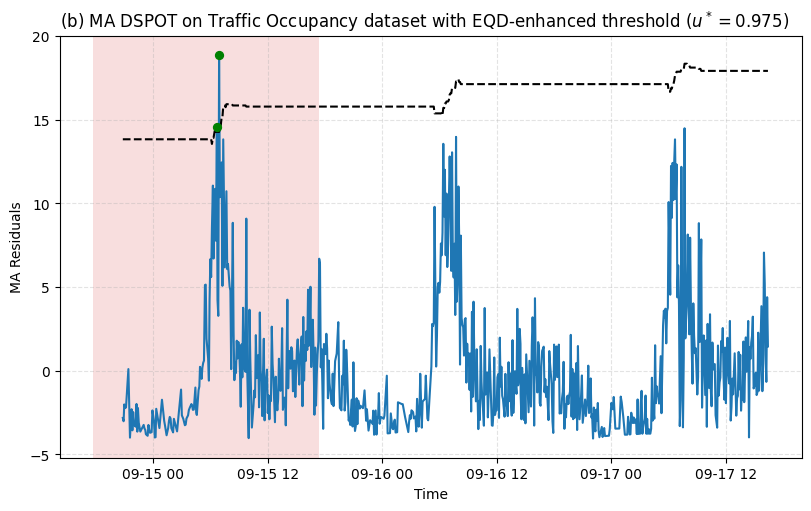

In [8]:
# Use the selected threshold for SPOT 
model = dSPOT(q=proba, depth = 288)
model.fit(init_data=init_batch, data=series_raw[init_data:].values)
model.initialize(level=level)
results = model.run()
fig, ax = model.plot(results,
    with_alarm=True,
    figsize=(8, 5),
    title=fr"(b) MA DSPOT on Traffic Occupancy dataset with EQD-enhanced threshold ($u^* = 0.975$)",
    show_legend=False,                 
    label="MA Residuals",
    data_color="tab:blue",           
    threshold_color="black", 
    true_alarm_color="green", 
    false_alarm_color="red",
    shade_color="tab:red", shade_alpha=0.15, 
    ts_index=full_index,                
    anomaly_windows=anomaly_windows_dt        
)
fig.savefig("../../output/occupancy/optimal_threshold_dspot_occupancy.png", dpi=300)   # Save before showing
plt.show()

In [9]:
## Event-based Evaluation
# Parameters + mapping 
offsets  = np.array(results["alarms"], dtype=int)
detected = timestamps.iloc[init_data + offsets].sort_values().to_list()

# Collapse consecutive alarms into alarm events
min_gap = pd.Timedelta("5min")
alarm_events = []
if detected:
    ev_start = detected[0]
    ev_end   = detected[0]
    for t in detected[1:]:
        if t - ev_end > min_gap:  
            alarm_events.append((ev_start, ev_end))
            ev_start = t
        ev_end = t
    alarm_events.append((ev_start, ev_end))

# Sort ground-truth windows + introduce "earliest unmatched" rule
gt_windows = sorted(list(anomaly_windows), key=lambda w: w[0])  # ensure sorted
TP, FP = 0, 0
delays = []
matched_gt = set()

for (a_start, a_end) in alarm_events:
    # find indices of ground-truth windows
    overlaps = [i for i, (g_start, g_end) in enumerate(gt_windows)
                if not (a_end < g_start or a_start > g_end)]
    if overlaps:
        # assign to earliest unmatched overlapping GT window, if any
        assigned = False
        for i in overlaps:
            if i not in matched_gt:
                matched_gt.add(i)
                TP += 1
                g_start = gt_windows[i][0]
                # define delay 
                delay_min = max(0.0, (a_start - g_start).total_seconds() / 60.0)
                delays.append(delay_min)
                assigned = True
                break
        if not assigned:
            pass
    else:
        FP += 1

FN = len(gt_windows) - TP

# Compute metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
recall    = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
f1        = (2 * precision * recall / (precision + recall)
             if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
             else float("nan"))
mean_delay   = np.nanmean(delays)  if delays else float("nan")
median_delay = np.nanmedian(delays) if delays else float("nan")

print(f"TP={TP}, FP={FP}, FN={FN}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
print(f"Median delay = {median_delay:.1f} min")


TP=1, FP=0, FN=0
Precision=1.000  Recall=1.000  F1=1.000
Median delay = 776.0 min


TP=1, FP=0, FN=0
Precision=1.000, Recall=1.000, F1=1.000
Mean delay = 776.0 min, Median delay = 776.0 min

### DSPOT Extensions for Stationary Residuals = ModifiedSPOT

EWMA + seasonal differencing + variance normalization on SPOT

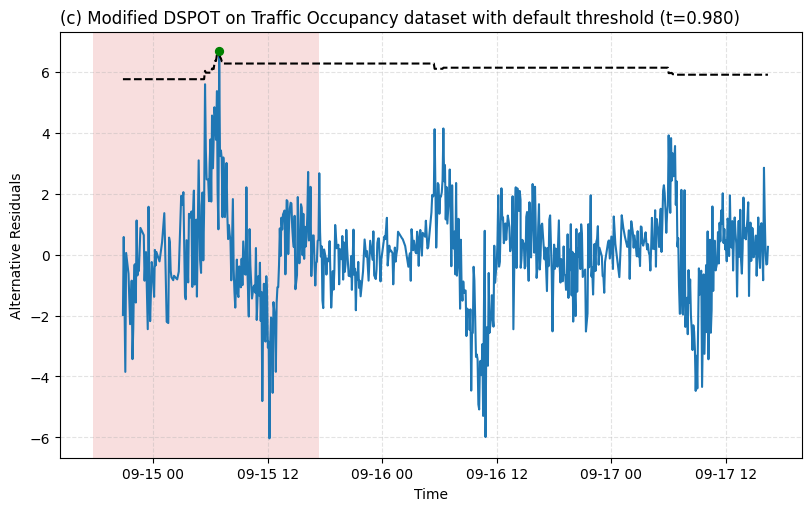

In [11]:
# Parameters
init_data = 1000
q = 1e-3

# Load data
df_clean = pd.read_csv("../../data/clean_data/post_gap_occupancy.csv", parse_dates=[0])
df_clean.columns = ["timestamp", "value"]
timestamps = df_clean["timestamp"]
series = df_clean["value"].values

# Split initial calibration and stream
init_series = series[:init_data]
stream_series = series[init_data:]
ts_stream = timestamps.iloc[init_data:]

# Run ModifiedSPOT
model = ModifiedSPOT(q=q, seasonal_period=288, ewma_alpha=0.05)
model.fit(init_data=init_series, data=stream_series)
model.initialize()
results = model.run()
fig, ax = model.plot(results,
    with_alarm=True,
    figsize=(8, 5),
    title="(c) Modified DSPOT on Traffic Occupancy dataset with default threshold (t=0.980)",
    show_legend=False,
    label="Alternative Residuals",
    data_color="tab:blue",           
    threshold_color="black", 
    true_alarm_color="green", 
    false_alarm_color="red",
    shade_color="tab:red", shade_alpha=0.15, 
    ts_index=full_index,                
    anomaly_windows=anomaly_windows_dt        
)
fig.savefig("../../output/occupancy/preprocessed_spot_occupancy.png", dpi=300)   # Save before showing
plt.show()

In [12]:
## Event-based Evaluation
# Parameters + mapping 
offsets  = np.array(results["alarms"], dtype=int)
detected = timestamps.iloc[init_data + offsets].sort_values().to_list()

# Collapse consecutive alarms into alarm events
min_gap = pd.Timedelta("5min")
alarm_events = []
if detected:
    ev_start = detected[0]
    ev_end   = detected[0]
    for t in detected[1:]:
        if t - ev_end > min_gap:  
            alarm_events.append((ev_start, ev_end))
            ev_start = t
        ev_end = t
    alarm_events.append((ev_start, ev_end))

# Sort ground-truth windows + introduce "earliest unmatched" rule
gt_windows = sorted(list(anomaly_windows), key=lambda w: w[0])  # ensure sorted
TP, FP = 0, 0
delays = []
matched_gt = set()

for (a_start, a_end) in alarm_events:
    # find indices of ground-truth windows
    overlaps = [i for i, (g_start, g_end) in enumerate(gt_windows)
                if not (a_end < g_start or a_start > g_end)]
    if overlaps:
        # assign to earliest unmatched overlapping GT window, if any
        assigned = False
        for i in overlaps:
            if i not in matched_gt:
                matched_gt.add(i)
                TP += 1
                g_start = gt_windows[i][0]
                # define delay 
                delay_min = max(0.0, (a_start - g_start).total_seconds() / 60.0)
                delays.append(delay_min)
                assigned = True
                break
        if not assigned:
            pass
    else:
        FP += 1

FN = len(gt_windows) - TP

# Compute metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
recall    = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
f1        = (2 * precision * recall / (precision + recall)
             if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
             else float("nan"))
mean_delay   = np.nanmean(delays)  if delays else float("nan")
median_delay = np.nanmedian(delays) if delays else float("nan")

print(f"TP={TP}, FP={FP}, FN={FN}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
print(f"Median delay = {median_delay:.1f} min")


TP=1, FP=0, FN=0
Precision=1.000  Recall=1.000  F1=1.000
Median delay = 790.0 min


WMA + seasonal diff + rolling-std + SPOT
TP          : 1.000
FP          : 0.000
FN          : 0.000
precision   : 1.000
recall      : 1.000
f1          : 1.000
mean_delay  : 790.000
median_delay: 790.000

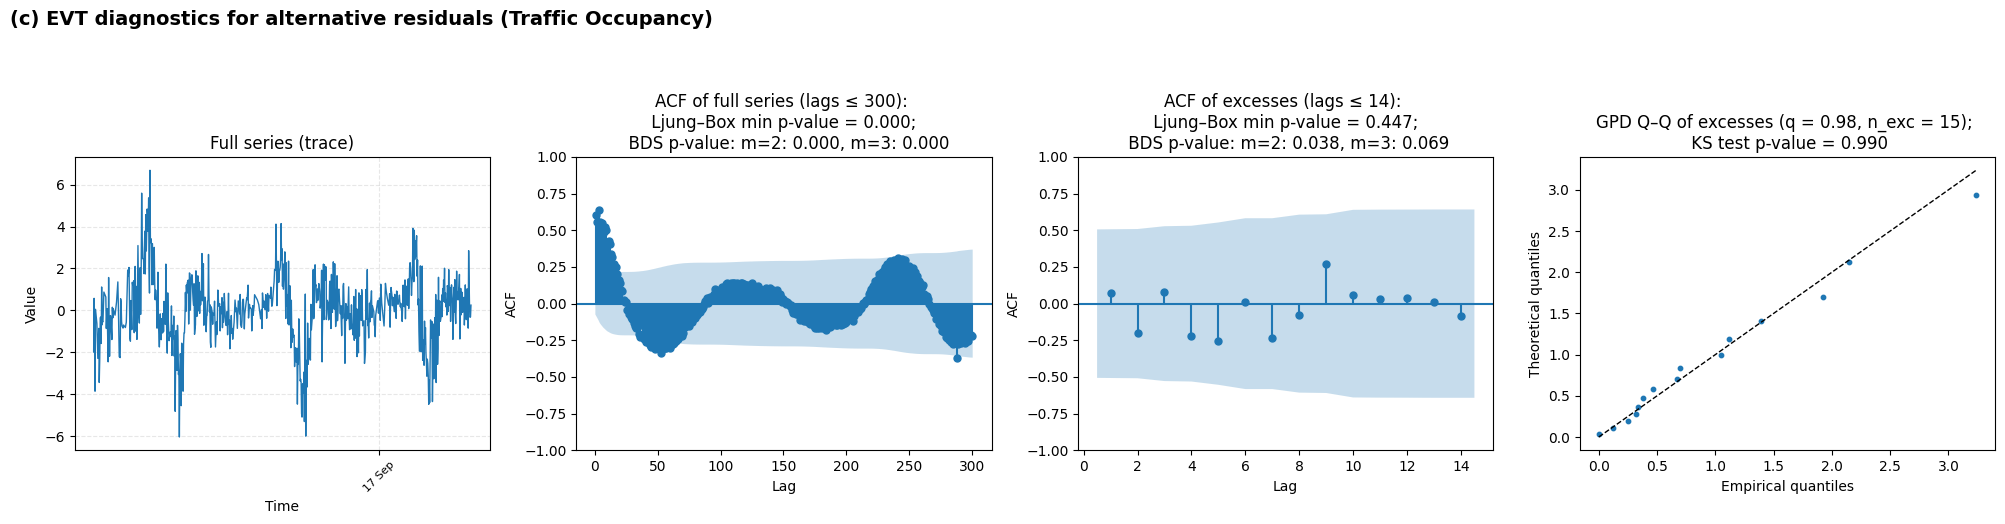

In [9]:
# print evt diagnostic for the residuals used in vanilla dSPOT
residuals  = np.array(results["residuals"])
raw_index = series_raw.index
resid_series = pd.Series(residuals, index=raw_index)
clean_resid = resid_series.dropna()

fig = plot_evt_diagnostics(clean_resid, exceed_q=0.98, acf_lags=300, bds_max_dim=3, 
                           title="(c) EVT diagnostics for alternative residuals (Traffic Occupancy)")
plt.show(fig)
fig.savefig("../../output/occupancy/evt_prep_diagnostics_occupancy.png", dpi=300, bbox_inches='tight')

Next, we use rigourosly chosen first cutoff threshold on the Vanilla DSPOT to see wether it will improve the fit

In [13]:
# Parameters
init_data = 1000
q = 1e-3

# Load data
df_clean = pd.read_csv("../../data/clean_data/post_gap_occupancy.csv", parse_dates=[0])
df_clean.columns = ["timestamp", "value"]
timestamps = df_clean["timestamp"]
series = df_clean["value"].values

# Split initial calibration and stream
init_series = series[:init_data]
stream_series = series[init_data:]
ts_stream = timestamps.iloc[init_data:]

# Preprocess init_series with the same logic as ModifiedSPOT
preproc = OnlinePreprocessor(P=288, alpha=0.05)
residuals = []
for x in init_series:
    z = preproc.update(x)
    if z is not None:
        residuals.append(z)
residuals = np.array(residuals)

# Run EQD on the preprocessed residuals
np.random.seed(27)
thresholds = np.quantile(residuals, np.linspace(0.85, 0.99, 30))
eqd_result = eqd(residuals, thresholds)
u_gpd = eqd_result["threshold"]
param = eqd_result["params"]

print("Selected threshold: ", u_gpd)
print("GPD parameters: ", param)
print("Estimated as quantile level: ", np.mean(residuals <= eqd_result["threshold"]))
print("Num peaks:", np.sum(residuals > u_gpd))
print("Max peak value:", residuals[residuals > u_gpd].max())
print("Mean peak value:", residuals[residuals > u_gpd].mean())

Selected threshold:  2.293118191304879
GPD parameters:  (0.7003576750106307, 0.0817310403160656)
Estimated as quantile level:  0.9311797752808989
Num peaks: 49
Max peak value: 6.826089385472109
Mean peak value: 3.0556998161923055


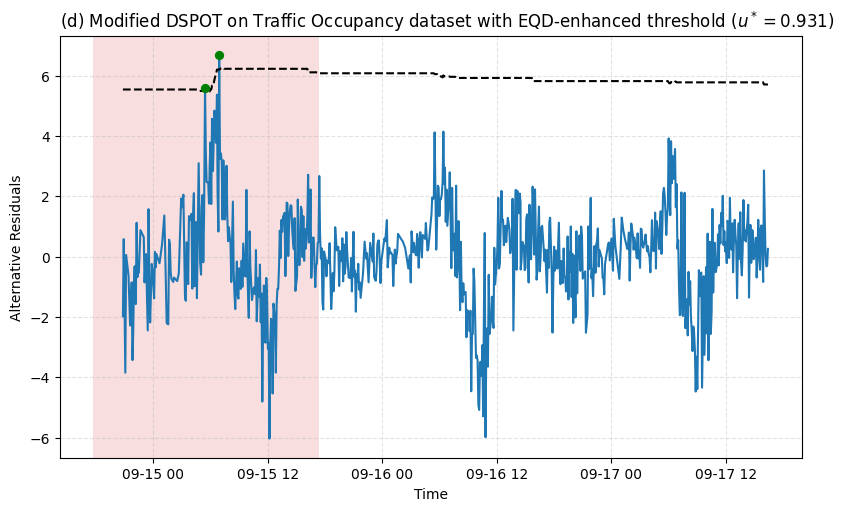

In [21]:
# Compute level
level = np.mean(residuals <= u_gpd)

# Run ModifiedSPOT
model = ModifiedSPOT(q=q, seasonal_period=288, ewma_alpha=0.05)
model.fit(init_data=init_series, data=stream_series)
model.initialize(level=level)
results = model.run()
fig, ax = model.plot(results,
    with_alarm=True,
    figsize=(8, 5),
    title=fr"(d) Modified DSPOT on Traffic Occupancy dataset with EQD-enhanced threshold ($u^* = 0.931$)",
    show_legend=False,
    label="Alternative Residuals",
    data_color="tab:blue",           
    threshold_color="black", 
    true_alarm_color="green", 
    false_alarm_color="red",
    shade_color="tab:red", shade_alpha=0.15, 
    ts_index=full_index,                
    anomaly_windows=anomaly_windows_dt        
)
fig.savefig("../../output/occupancy/optimal_threshold_preprocessed_spot_occupancy.png", dpi=300)   # Save before showing
plt.show()

In [15]:
## Event-based Evaluation
# Parameters + mapping 
offsets  = np.array(results["alarms"], dtype=int)
detected = timestamps.iloc[init_data + offsets].sort_values().to_list()

# Collapse consecutive alarms into alarm events
min_gap = pd.Timedelta("5min")
alarm_events = []
if detected:
    ev_start = detected[0]
    ev_end   = detected[0]
    for t in detected[1:]:
        if t - ev_end > min_gap:  
            alarm_events.append((ev_start, ev_end))
            ev_start = t
        ev_end = t
    alarm_events.append((ev_start, ev_end))

# Sort ground-truth windows + introduce "earliest unmatched" rule
gt_windows = sorted(list(anomaly_windows), key=lambda w: w[0])  # ensure sorted
TP, FP = 0, 0
delays = []
matched_gt = set()

for (a_start, a_end) in alarm_events:
    # find indices of ground-truth windows
    overlaps = [i for i, (g_start, g_end) in enumerate(gt_windows)
                if not (a_end < g_start or a_start > g_end)]
    if overlaps:
        # assign to earliest unmatched overlapping GT window, if any
        assigned = False
        for i in overlaps:
            if i not in matched_gt:
                matched_gt.add(i)
                TP += 1
                g_start = gt_windows[i][0]
                # define delay 
                delay_min = max(0.0, (a_start - g_start).total_seconds() / 60.0)
                delays.append(delay_min)
                assigned = True
                break
        if not assigned:
            pass
    else:
        FP += 1

FN = len(gt_windows) - TP

# Compute metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
recall    = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
f1        = (2 * precision * recall / (precision + recall)
             if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
             else float("nan"))
mean_delay   = np.nanmean(delays)  if delays else float("nan")
median_delay = np.nanmedian(delays) if delays else float("nan")

print(f"TP={TP}, FP={FP}, FN={FN}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
print(f"Median delay = {median_delay:.1f} min")


TP=1, FP=0, FN=0
Precision=1.000  Recall=1.000  F1=1.000
Median delay = 701.0 min


EWMA + seasonal diff + rolling-std + SPOT
TP          : 1.000
FP          : 0.000
FN          : 0.000
precision   : 1.000
recall      : 1.000
f1          : 1.000
mean_delay  : 751.000
median_delay: 751.000

### Compute Wilson CI for each DSPOT variant

In [16]:
from math import sqrt

def wilson_ci(tp, fp_or_fn, z=1.96, kind="precision"):
    if kind == "precision":
        x, n = tp, tp + fp_or_fn
    else:  # recall
        x, n = tp, tp + fp_or_fn
    if n == 0:
        return float('nan'), float('nan'), float('nan')  # NA
    phat = x / n
    denom = 1 + z*z/n
    center = (phat + z*z/(2*n)) / denom
    radius = (z * sqrt(phat*(1-phat)/n + z*z/(4*n*n))) / denom
    return phat, center - radius, center + radius

def format_metric(tp, fp, fn, f1):
    p, p_lo, p_hi = wilson_ci(tp, fp, kind="precision")
    r, r_lo, r_hi = wilson_ci(tp, fn, kind="recall")
    return (f"{p:.3f} [{p_lo:.3f}, {p_hi:.3f}]",
            f"{r:.3f} [{r_lo:.3f}, {r_hi:.3f}]",
            f"{f1:.3f}")

In [19]:
# All models for Traffic Data
format_metric(1, 0, 0, 1) #TP,FP,FN,F1

('1.000 [0.207, 1.000]', '1.000 [0.207, 1.000]', '1.000')